# TAHAP 01 — Dataset Construction dan Baseline Modeling Chatbot ApotekCare

Notebook ini digunakan untuk membangun dataset, melakukan preprocessing teks, membangun baseline model intent classification, serta melakukan evaluasi awal untuk chatbot layanan apotek.

## 1. Import Library
Library yang digunakan meliputi pandas untuk pengolahan data, scikit-learn untuk TF-IDF dan supervised learning, serta matplotlib untuk visualisasi.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Dataset
Dataset terdiri dari FAQ, intent classification, katalog produk, dan pertanyaan di luar konteks.

In [2]:
faq_df = pd.read_csv('../data/raw/faq_apotekcare.csv')
intent_df = pd.read_csv('../data/raw/intent_dataset.csv')
product_df = pd.read_csv('../data/raw/product_catalog.csv')
out_scope_df = pd.read_csv('../data/raw/out_of_scope_questions.csv')

display(faq_df.head())
display(intent_df.head())
display(product_df.head())
display(out_scope_df.head())

,faq_id,question,answer,intent,safety_note
0,FAQ001,Apotek ini buka jam berapa?,ApotekCare buka setiap hari pukul 08.00 sampai...,info_jam_operasional,Tidak ada
1,FAQ002,Apakah ApotekCare buka hari Minggu?,"Ya, ApotekCare tetap buka pada hari Minggu puk...",info_jam_operasional,Tidak ada
2,FAQ003,Apakah bisa pesan obat lewat chat?,Bisa. Pelanggan dapat menanyakan ketersediaan ...,info_pemesanan,Tidak ada
3,FAQ004,Apakah ApotekCare menyediakan layanan antar?,"Ya, ApotekCare menyediakan layanan antar untuk...",info_pengiriman,Tidak ada
4,FAQ005,Metode pembayaran apa saja yang tersedia?,"Pembayaran dapat dilakukan secara tunai, trans...",info_pembayaran,Tidak ada


,text,intent
0,halo,greeting
1,halo admin,greeting
2,halo saya mau bertanya,greeting
3,hai apotekcare,greeting
4,hai apotekcare admin,greeting


,product_id,product_name,category,related_intent,description,recommendation_rule,safety_note
0,PRD001,Obat batuk bebas,Obat bebas,rekomendasi_batuk_flu,Produk untuk membantu meredakan batuk ringan.,Ditampilkan jika user bertanya batuk ringan.,Baca aturan pakai dan konsultasi apoteker.
1,PRD002,Pelega tenggorokan,Obat bebas/produk kesehatan,rekomendasi_batuk_flu,Produk untuk membantu meredakan tenggorokan ti...,Ditampilkan untuk keluhan tenggorokan gatal.,Tidak untuk keluhan berat tanpa konsultasi.
2,PRD003,Minyak kayu putih,Produk kesehatan,rekomendasi_batuk_flu,Produk luar untuk rasa hangat dan kenyamanan t...,Ditampilkan untuk flu ringan atau masuk angin.,Pemakaian luar.
3,PRD004,Obat penurun panas bebas,Obat bebas,rekomendasi_demam_nyeri,Produk untuk demam atau nyeri ringan sesuai at...,Ditampilkan untuk demam ringan atau nyeri ringan.,"Jika demam tinggi/berulang, konsultasi dokter."
4,PRD005,Termometer digital,Alat kesehatan,rekomendasi_demam_nyeri,Alat untuk mengukur suhu tubuh.,Ditampilkan untuk pertanyaan demam atau cek suhu.,Bukan alat diagnosis mandiri.


,question,expected_response,label
0,Siapa presiden Indonesia?,"Maaf, pertanyaan tersebut di luar layanan Apot...",out_of_scope
1,Tolong buatkan puisi cinta,"Maaf, saya hanya membantu informasi layanan ap...",out_of_scope
2,Bagaimana cara membuat website?,"Maaf, pertanyaan tersebut tidak terkait layana...",out_of_scope
3,Rekomendasi laptop gaming apa?,"Maaf, saya hanya membantu kebutuhan layanan ap...",out_of_scope
4,Berapa harga emas hari ini?,"Maaf, pertanyaan tersebut di luar konteks Apot...",out_of_scope


## 3. Preprocessing Teks
Tahapan preprocessing mencakup case folding, penghapusan tanda baca, dan normalisasi spasi.

In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

intent_df['clean_text'] = intent_df['text'].apply(preprocess_text)
intent_df.head()

,text,intent,clean_text
0,halo,greeting,halo
1,halo admin,greeting,halo admin
2,halo saya mau bertanya,greeting,halo saya mau bertanya
3,hai apotekcare,greeting,hai apotekcare
4,hai apotekcare admin,greeting,hai apotekcare admin


## 4. Visualisasi Distribusi Intent
Visualisasi ini membantu melihat keseimbangan jumlah data pada setiap intent.

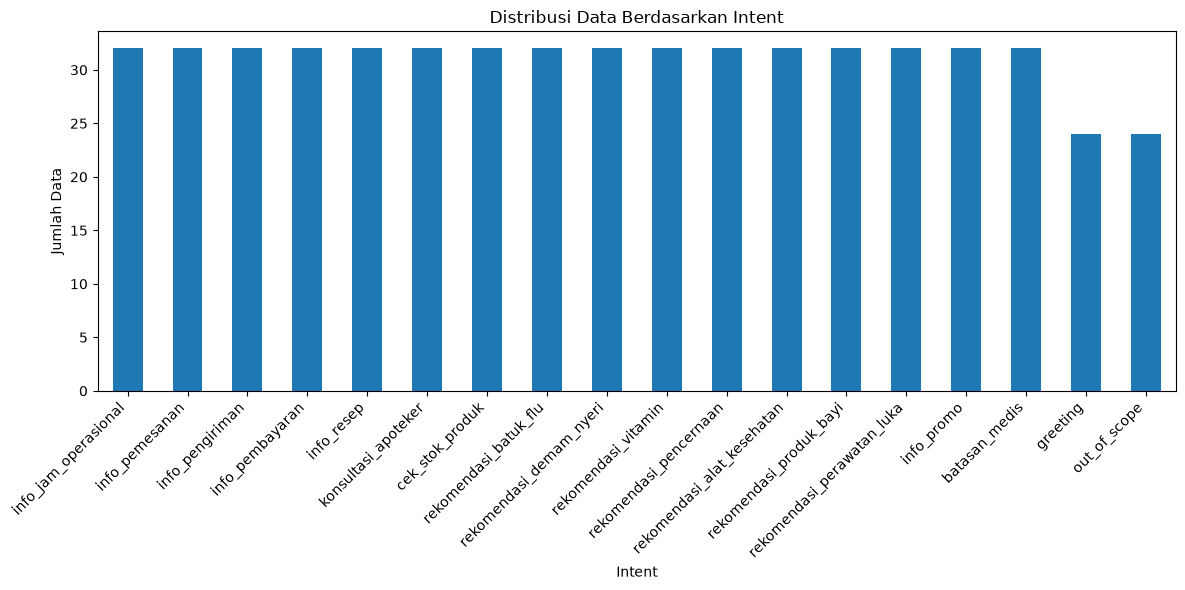

In [4]:
intent_counts = intent_df['intent'].value_counts()
plt.figure(figsize=(12, 6))
intent_counts.plot(kind='bar')
plt.title('Distribusi Data Berdasarkan Intent')
plt.xlabel('Intent')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Split Dataset dan TF-IDF
Data dibagi menjadi data latih dan data uji. Teks diubah menjadi fitur numerik menggunakan TF-IDF Vectorizer.

In [5]:
X = intent_df['clean_text']
y = intent_df['intent']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 6. Baseline Model Logistic Regression
Model pertama yang diuji adalah Logistic Regression karena sesuai untuk klasifikasi teks berbasis fitur TF-IDF.

In [6]:
logreg_model = LogisticRegression(max_iter=1000, random_state=42)
logreg_model.fit(X_train_tfidf, y_train)
y_pred_logreg = logreg_model.predict(X_test_tfidf)

print('Accuracy Logistic Regression:', accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg, target_names=label_encoder.classes_, zero_division=0))

Accuracy Logistic Regression: 0.9642857142857143
                            precision    recall  f1-score   support

             batasan_medis       1.00      1.00      1.00         6
           cek_stok_produk       0.75      0.50      0.60         6
                  greeting       1.00      1.00      1.00         5
      info_jam_operasional       1.00      1.00      1.00         6
           info_pembayaran       1.00      1.00      1.00         7
            info_pemesanan       1.00      1.00      1.00         7
           info_pengiriman       1.00      1.00      1.00         6
                info_promo       1.00      1.00      1.00         7
                info_resep       1.00      1.00      1.00         7
       konsultasi_apoteker       1.00      1.00      1.00         6
              out_of_scope       1.00      1.00      1.00         5
rekomendasi_alat_kesehatan       0.62      0.83      0.71         6
     rekomendasi_batuk_flu       1.00      1.00      1.00         

## 7. Baseline Model Multinomial Naive Bayes
Model kedua yang diuji adalah Multinomial Naive Bayes, salah satu algoritma klasik yang sering digunakan dalam klasifikasi teks.

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print('Accuracy Multinomial Naive Bayes:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=label_encoder.classes_, zero_division=0))

Accuracy Multinomial Naive Bayes: 0.9732142857142857
                            precision    recall  f1-score   support

             batasan_medis       1.00      1.00      1.00         6
           cek_stok_produk       0.71      0.83      0.77         6
                  greeting       1.00      1.00      1.00         5
      info_jam_operasional       1.00      1.00      1.00         6
           info_pembayaran       1.00      1.00      1.00         7
            info_pemesanan       1.00      1.00      1.00         7
           info_pengiriman       1.00      1.00      1.00         6
                info_promo       1.00      1.00      1.00         7
                info_resep       1.00      1.00      1.00         7
       konsultasi_apoteker       1.00      1.00      1.00         6
              out_of_scope       1.00      1.00      1.00         5
rekomendasi_alat_kesehatan       0.80      0.67      0.73         6
     rekomendasi_batuk_flu       1.00      1.00      1.00     

## 8. Confusion Matrix
Confusion matrix digunakan untuk melihat intent mana yang sudah terklasifikasi dengan baik dan intent mana yang masih berpotensi tertukar.

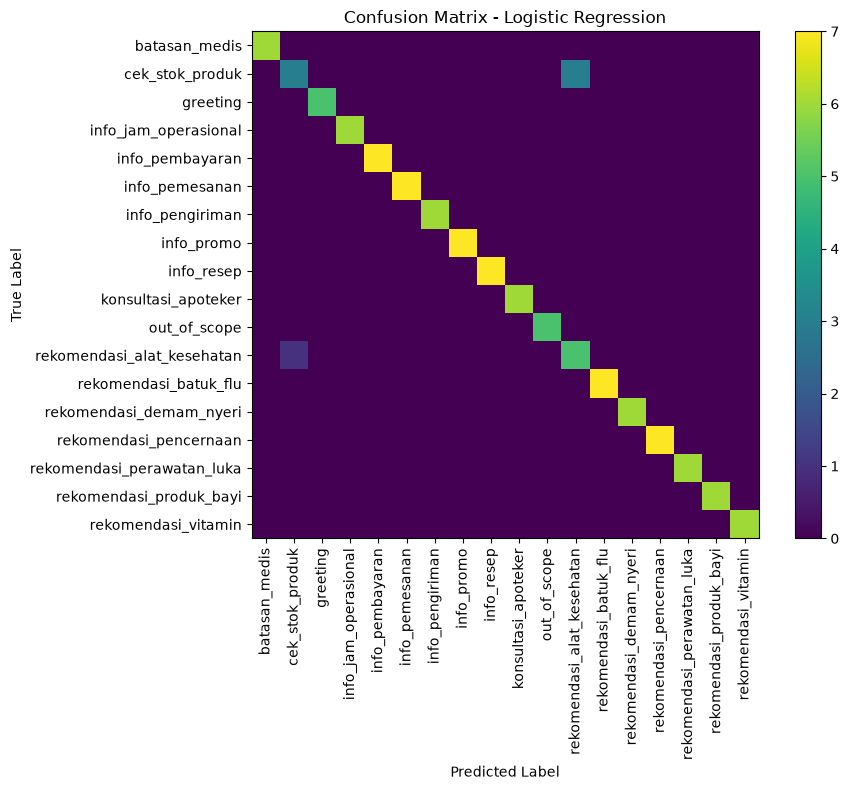

In [8]:
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(ticks=np.arange(len(label_encoder.classes_)), labels=label_encoder.classes_, rotation=90)
plt.yticks(ticks=np.arange(len(label_encoder.classes_)), labels=label_encoder.classes_)
plt.colorbar()
plt.tight_layout()
plt.show()

## 9. Interpretasi
Model baseline dievaluasi menggunakan accuracy, precision, recall, dan F1-score. Model terbaik dapat digunakan sebagai dasar integrasi chatbot pada dashboard Streamlit. Dataset masih bersifat simulatif sehingga perlu diperluas jika ingin digunakan pada skenario operasional nyata.